# Forecast Time Series For A RAWS Station

In this example, we will use WxData to download and plot the 7-Day NFDRS Forecast for 100-HR Dead Fuel Moisture For Acton RAWS (45438)

**If you are getting SSL Certificate Errors when trying to download data, you may be using a proxy server connection**

We will not be doing any proxy connection examples. 

How to set up a proxy:

proxies (dict or None) - Default=None. If the user is using proxy server(s), the user must change the following:

       proxies=None ---> proxies={
                               'http':'http://your-proxy-address:port',
                               'https':'http://your-proxy-address:port'
                               }

For more information on configuring proxies: https://requests.readthedocs.io/en/latest/user/advanced/#proxies

## Imports

In [1]:
import matplotlib.pyplot as plt
import matplotlib.dates as md
import matplotlib.colors as mcolors
import pandas as pd

from wxdata import get_single_raws_station_nfdrs_forecast
from matplotlib.ticker import MaxNLocator 

## Retrieving Our Fuels Data

We will need to retrieve our data using `get_single_raws_station_nfdrs_forecast()`

Here is the documentation for `get_single_raws_station_nfdrs_forecast()`

***def get_single_raws_station_nfdrs_forecast(station_id, 
                                        fuel_model='Y', 
                                        clear_recycle_bin=False,
                                        path=f'{folder_modified}/FEMS Data/Single Station/NFDRS Forecasts',
                                        proxies=None,
                                        clear_data=True,
                                        meta_path=f'{folder_modified}/FEMS Data/Station Meta Data',
                                        sheet_name='Sheet1'):***

This function retrieves the 7-Day NFDRS (fuels) forecast for a user-specified single RAWS station. 

Required Arguments:

1) station_id (Integer) - The RAWS ID of the station. 

Optional Arguments:

1) fuel_model (String) - Default = 'Y'. The fuel model being used. 
    Fuel Models List:

    Y - Timber
    X - Brush
    W - Grass/Shrub
    V - Grass
    Z - Slash

2) clear_recycle_bin (Boolean) - Default=False. When set to True, the contents in your recycle/trash bin will be deleted 
    with each run of the program you are calling WxData. This setting is to help preserve memory on the machine. 
    
3) path (String) - Default=f'{folder_modified}/FEMS Data/Single Station/NFDRS Forecasts'. 
    The directory the data will be saved to. 
    
4) proxies (dict or None) - Default=None. If the user is using proxy server(s), the user must change the following:

   proxies=None ---> proxies={
                           'http':'http://your-proxy-address:port',
                           'https':'http://your-proxy-address:port'
                           }

5) clear_data (Boolean) - Default=True. When set to True, the data directory clears out and new data is downloaded.

6) meta_path (String) - Default=f'{folder_modified}/FEMS Data/Station Meta Data'. 
    The path to where the RAWS station meta data excel file will be saved to. 
    
7) sheet_name (String) - The name of the sheet in the excel file to be converted into a pandas.DataFrame.

**Returns**

1) A Pandas DataFrame of 7-Day NFDRS (fuels) forecast data for a user-specified single RAWS station.   
2) A Pandas DataFrame of the RAWS Station Meta-Data.        

In [2]:
df, meta = get_single_raws_station_nfdrs_forecast(45438)

In [3]:
df

,stationName,observationTime,NFDRType,fuelModelType,oneHR_TL_FuelMoisture,tenHR_TL_FuelMoisture,hundredHR_TL_FuelMoisture,thousandHR_TL_FuelMoisture,kbdi,gsi,woodyLFI_fuelMoisture,herbaceousLFI_fuelMoisture,ignitionComponent,energyReleaseComponent,spreadComponent,burningIndex,NFDRQAFlag
0,ACTON,2026-04-09T07:00:00.000Z,F,Y,10.68,8.00,12.59,15.06,719,0.07,60,30,10.44,35.00,1.87,20.62,0
1,ACTON,2026-04-09T08:00:00.000Z,F,Y,11.61,8.02,12.58,15.20,719,0.07,60,30,8.29,34.19,1.81,20.06,0
2,ACTON,2026-04-09T09:00:00.000Z,F,Y,12.70,8.32,12.56,15.19,719,0.07,60,30,6.30,33.48,1.74,19.51,0
3,ACTON,2026-04-09T10:00:00.000Z,F,Y,13.46,8.80,12.62,15.19,719,0.07,60,30,5.14,32.83,1.69,19.08,0
4,ACTON,2026-04-09T11:00:00.000Z,F,Y,14.41,9.44,12.61,15.18,719,0.07,60,30,3.86,32.05,1.63,18.55,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163,ACTON,2026-04-16T02:00:00.000Z,F,Y,6.65,9.43,17.33,20.33,710,0.23,60,30,31.75,22.55,3.29,21.82,0
164,ACTON,2026-04-16T03:00:00.000Z,F,Y,7.34,9.13,17.15,20.26,710,0.23,60,30,25.79,22.59,2.89,20.58,0
165,ACTON,2026-04-16T04:00:00.000Z,F,Y,8.60,9.00,17.02,20.21,710,0.23,60,30,18.46,22.28,2.47,19.01,0
166,ACTON,2026-04-16T05:00:00.000Z,F,Y,10.01,9.03,16.92,20.17,710,0.23,60,30,12.73,21.79,2.11,17.51,0


In [4]:
meta

,Goober Reason,station_id,wrcc_id,period_record_start,period_record_stop,nesdis_id,station_name,state,county,latitude,...,region,unit,transmit_time,tx_frequency,obs_frequency,site_description,goes,maintenance_standard,time_zone,avg_annual_precip
1855,NaN,45438,CACT,2005-01-01,2022-12-31,CA4A7044,ACTON,CA,Los Angeles,34.446389,...,CALIFORNIA,LOS ANGELES COUNTY,2.284722,60,60,"Northside of San Gabriels, in foothills of Pin...",West,Yes,PST,10.56


## Plotting Our Data

Text(0.01, 0.01, 'Plot Created by Eric J. Drewitz - Powered by WxData')

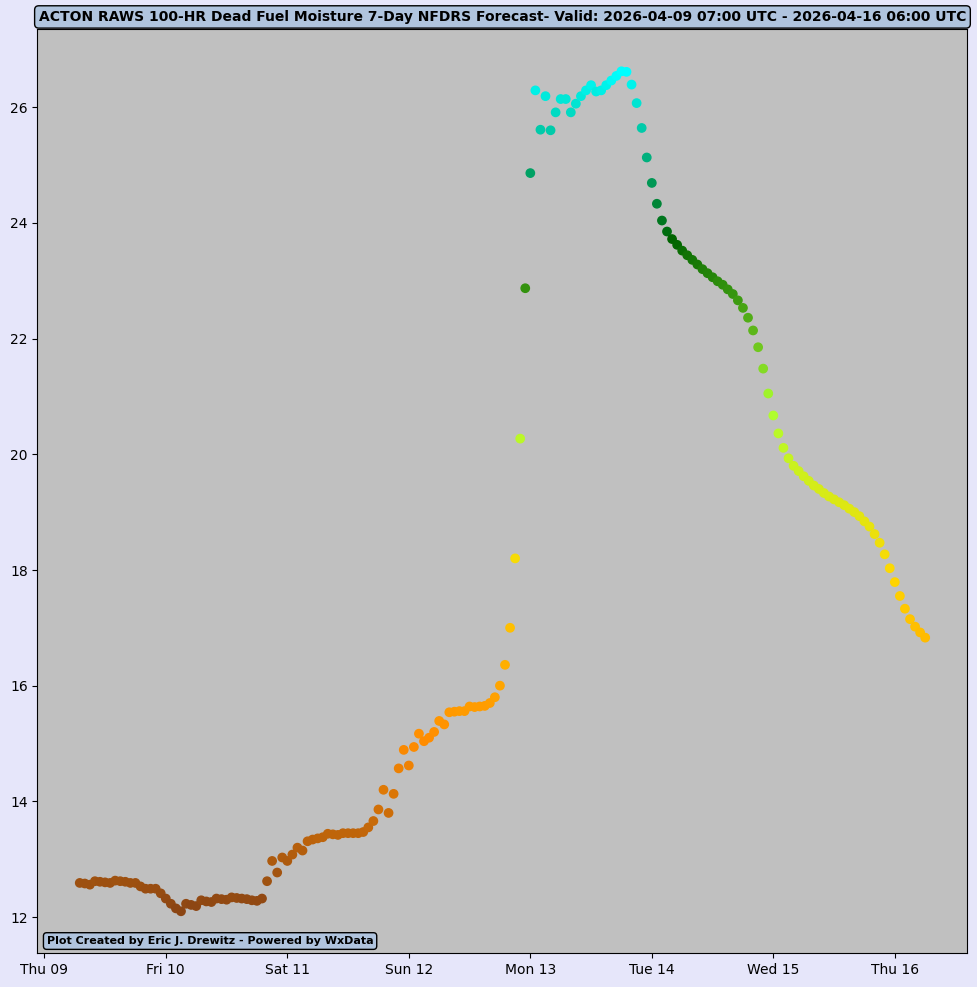

In [5]:
# Create our figure
fig = plt.figure(figsize=(12,12))

# Set facecolor of plot
fig.set_facecolor('lavender')

# Create our subplot axis
ax = fig.add_subplot(1,1,1)

# Set the background of the plot to grey
ax.set_facecolor('silver')

# Format the x-axis so it reflects datetime
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.xaxis.set_major_formatter(md.DateFormatter('%a %d'))

# Create a custom colormap
cmap = mcolors.LinearSegmentedColormap.from_list("100hr dead fuel moisture", ["saddlebrown", "darkorange", "gold", "greenyellow", "darkgreen", "cyan"])

ax.scatter(pd.to_datetime(df['observationTime']), df['hundredHR_TL_FuelMoisture'], c=df['hundredHR_TL_FuelMoisture'], cmap=cmap)

# Create a textbox
box = dict(boxstyle='round', facecolor='lightsteelblue')

# Create our title for our plot
ax.set_title(f"{df['stationName'].iloc[0]} RAWS 100-HR Dead Fuel Moisture 7-Day NFDRS Forecast- Valid: {pd.to_datetime(df['observationTime'].iloc[0]).strftime('%Y-%m-%d %H:00 UTC')} - {pd.to_datetime(df['observationTime'].iloc[-1]).strftime('%Y-%m-%d %H:00 UTC')}", 
             fontweight='bold', 
             fontsize=10,
             bbox=box)

# Create a signature
ax.text(0.01, 0.01, f"Plot Created by Eric J. Drewitz - Powered by WxData", 
        transform=ax.transAxes, 
        fontweight='bold',
        fontsize=8,
        bbox=box)